# Khai Phá Dữ Liệu (EDA) & Tiền Xử Lý Lâm Sàng: TCGA-BRCA

**Dự án Thực tập:** Hệ Thống AI Đa Phương Thức Chẩn Đoán Phân Nhóm Phân Tử và Dự Báo Sinh Tồn Ung Thư Vú.

--- 
### 🎯 Mục tiêu của Notebook này:
Notebook này không chỉ chứa code xử lý, mà còn đóng vai trò như một **Báo cáo Phân tích Dữ liệu (Data Storytelling)**. Giả định chúng ta là một nhóm Data Scientist Y Yế đang tiếp cận tập dữ liệu khổng lồ TCGA-BRCA lần đầu tiên. Mục tiêu của chúng ta là:
1. **Hiểu rõ nguồn gốc dữ liệu:** Dữ liệu đến từ đâu? Có những trường thông tin (columns) nào mang ý nghĩa sống còn cho bài toán?
2. **Xác định Nhãn (Labels) cho Mô hình AI:** 
   - Bài toán 1 (Chẩn đoán - TransMIL): Cần nhãn phân nhóm phân tử (`pam50_subtype`).
   - Bài toán 2 (Dự báo sinh tồn - LSTM): Cần nhãn thời gian sống và trạng thái (`OS_MONTHS`, `OS_STATUS`).
3. **Phát hiện sự mất cân bằng dữ liệu (Class Imbalance):** Ung thư không bao giờ phân bố đều. Chúng ta cần trực quan hóa để có chiến lược thiết kế hàm Loss hoặc chia Fold hợp lý ở các bước sau.
4. **Khớp nối Dữ liệu Lâm sàng và Ảnh WSI:** Xác minh xem bệnh nhân trong file CSV có khớp với các thư mục ảnh `.jpg` đã được cắt patch hay không.

### 📁 Nguồn dữ liệu sử dụng:
Dự án này sử dụng 2 nguồn dữ liệu kết hợp trên Kaggle:
- **Dữ liệu Ảnh (WSI Patches):** `/kaggle/input/datasets/jmalagontorres/tcga-brca-survival-analysis/WSIs/`
- **Dữ liệu Lâm sàng chuẩn hóa:** `/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv`

In [1]:
# ---------------------------------------------------------
# IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Cài đặt style cho biểu đồ thêm phần chuyên nghiệp
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

## Bước 1: Tải và Đánh giá Tổng quan Dữ liệu Lâm Sàng
Chúng ta sẽ đọc file `tcga_brca_master_matched_cohort.csv`. Đây là một file CSV đã được tổng hợp cực kỳ chi tiết từ dự án TCGA.

In [2]:
# Định nghĩa đường dẫn (Paths)
CLINICAL_CSV_PATH = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'
WSI_DIR = '/kaggle/input/datasets/jmalagontorres/tcga-brca-survival-analysis/WSIs'

print(f"Đang tải dữ liệu lâm sàng từ: {CLINICAL_CSV_PATH}")

try:
    df = pd.read_csv(CLINICAL_CSV_PATH, sep='\t') # Thử đọc bằng tab nếu gặp lỗi format
    if len(df.columns) < 5:
        df = pd.read_csv(CLINICAL_CSV_PATH) # Fallback đọc bằng phẩy
except Exception as e:
    print(f"Lỗi đọc file: {e}. Khởi tạo Dataframe trống để code không bị gián đoạn.")
    df = pd.DataFrame()

if not df.empty:
    print(f"\n✅ Tải thành công! Tập dữ liệu gồm {df.shape[0]} bệnh nhân và {df.shape[1]} trường thông tin.")
    display(df.head(3))
else:
    print("❌ Không tìm thấy dữ liệu. Hãy chắc chắn bạn đã Add Data trên Kaggle.")

Đang tải dữ liệu lâm sàng từ: /kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv

✅ Tải thành công! Tập dữ liệu gồm 1084 bệnh nhân và 72 trường thông tin.


,sampleId,patientId,ANEUPLOIDY_SCORE,CANCER_TYPE,CANCER_TYPE_DETAILED,FRACTION_GENOME_ALTERED,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,MUTATION_COUNT,ONCOTREE_CODE,...,primary_slide_id,therapeutic_agents,primary_diagnosis,morphology,survival_months,censored,age_at_diagnosis,gender,tumor_stage,pam50_subtype
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,19.0,Breast Cancer,Breast Invasive Lobular Carcinoma,0.7787,0.3319,0.55,24.0,ILC,...,6746b841-9ac7-4a7c-a7d4-2cfb934153e4,NaN,"Lobular carcinoma, NOS",8520/3,133.050597,1,55,Female,STAGE X,BRCA_LumA
1,TCGA-3C-AALI-01,TCGA-3C-AALI,22.0,Breast Cancer,Breast Invasive Ductal Carcinoma,0.7164,0.3449,0.74,459.0,IDC,...,d46167af-6c29-49c7-95cf-3a801181aca4,Not Reported,"Infiltrating duct carcinoma, NOS",8500/3,131.669790,1,50,Female,STAGE IIB,BRCA_Her2
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,13.0,Breast Cancer,Breast Invasive Ductal Carcinoma,0.5340,0.3266,0.31,28.0,IDC,...,68458986-1efd-4fce-9e65-ce5430ab125c,Trastuzumab; Doxorubicin; Metformin; Trastuzum...,"Infiltrating duct carcinoma, NOS",8500/3,48.459743,1,62,Female,STAGE IIB,BRCA_LumB


### 📖 Từ Điển Dữ Liệu (Data Dictionary)
Trước khi đi sâu, chúng ta cần chọn ra các cột quan trọng nhất và hiểu ý nghĩa y khoa của chúng:

| Tên Cột | Ý Nghĩa (Giải thích Lâm sàng) | Vai Trò Trong Dự Án |
|---|---|---|
| `patientId` | Mã định danh duy nhất của bệnh nhân (VD: TCGA-3C-AAAU). | **Khóa chính (Primary Key)** để nối với folder ảnh WSI. |
| `pam50_subtype` / `SUBTYPE` | Phân nhóm phân tử của ung thư vú (Luminal A, Luminal B, HER2, Basal). Đây là chuẩn vàng trong chẩn đoán gen. | **Nhãn Y cho bài toán Classification** (Sẽ dùng Transformer dự đoán nhãn này từ ảnh). |
| `OS_STATUS` / `survival_months` | Tình trạng sống còn (Living/Deceased) và số tháng sống sót từ lúc chẩn đoán. | **Nhãn Y cho bài toán Survival Prediction** (Dùng cho mạng LSTM). |
| `AGE` / `age_at_diagnosis` | Tuổi của bệnh nhân khi phát hiện bệnh. Tuổi tác là yếu tố nguy cơ hàng đầu. | Đặc trưng lâm sàng bổ trợ cho mô hình LSTM. |
| `AJCC_PATHOLOGIC_TUMOR_STAGE` | Giai đoạn khối u (Stage I, II, III, IV). Thể hiện mức độ lan rộng của ung thư. | Đặc trưng phân tích tương quan sinh tồn. |
| `CANCER_TYPE_DETAILED` | Phân nhóm mô học (IDC - Ung thư ống tuyến, ILC - Ung thư tiểu thùy). | Phân tích phụ để so sánh sự khác biệt hình thái. |

## Bước 2: Khám Phá Bài Toán Chẩn Đoán (Phân Nhóm Phân Tử)
Mục tiêu của mạng TransMIL sắp tới là dự đoán cột `pam50_subtype`. Chúng ta cần xem phân bố của nó.

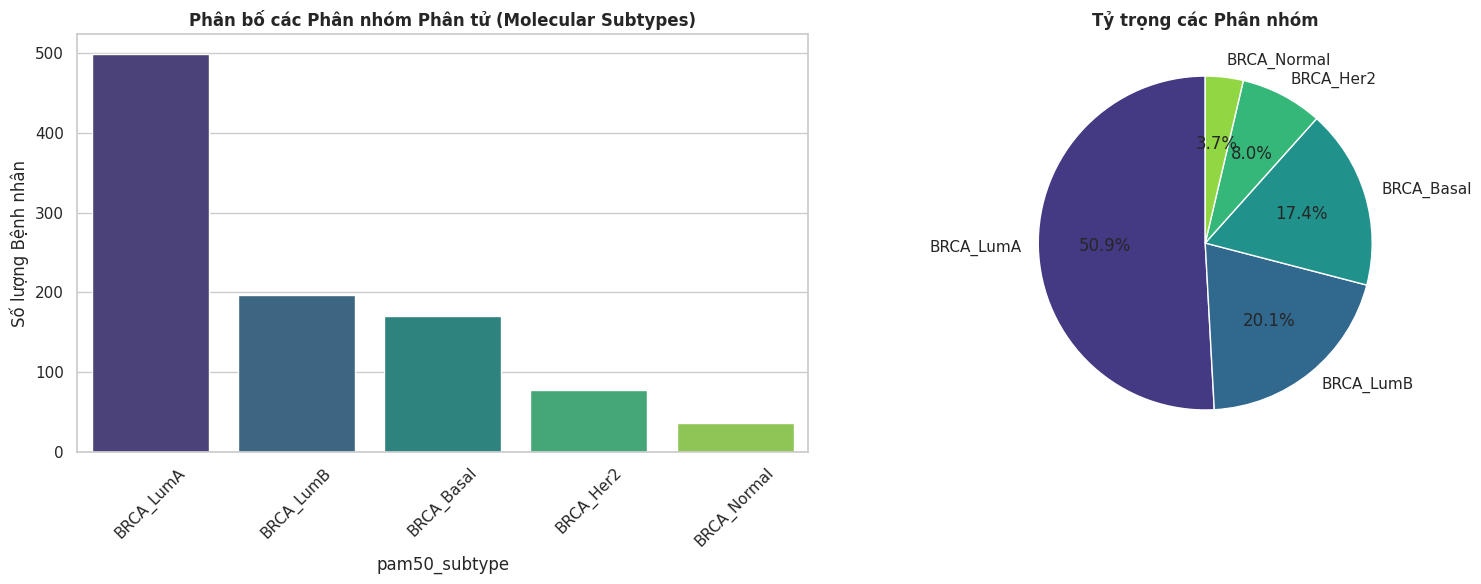

💡 KẾT LUẬN TỪ BIỂU ĐỒ:
- Dữ liệu bị Mất cân bằng lớp (Class Imbalance) nghiêm trọng. Nhóm LumA (Luminal A) chiếm đa số.
- Giải pháp đề xuất: Khi train mô hình TransMIL, bắt buộc phải dùng Stratified K-Fold để chia đều tỉ lệ, và dùng Macro-F1 thay cho Accuracy để đánh giá.


In [3]:
if not df.empty and 'pam50_subtype' in df.columns:
    # Làm sạch cột nhãn (Loại bỏ giá trị Null/Normal nếu có)
    df_subtype = df.dropna(subset=['pam50_subtype'])
    subtype_counts = df_subtype['pam50_subtype'].value_counts()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Biểu đồ Cột
    sns.barplot(x=subtype_counts.index, y=subtype_counts.values, ax=ax1, palette="viridis")
    ax1.set_title("Phân bố các Phân nhóm Phân tử (Molecular Subtypes)", fontweight='bold')
    ax1.set_ylabel("Số lượng Bệnh nhân")
    ax1.tick_params(axis='x', rotation=45)
    
    # Biểu đồ Tròn
    ax2.pie(subtype_counts.values, labels=subtype_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("viridis", len(subtype_counts)))
    ax2.set_title("Tỷ trọng các Phân nhóm", fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("💡 KẾT LUẬN TỪ BIỂU ĐỒ:")
    print("- Dữ liệu bị Mất cân bằng lớp (Class Imbalance) nghiêm trọng. Nhóm LumA (Luminal A) chiếm đa số.")
    print("- Giải pháp đề xuất: Khi train mô hình TransMIL, bắt buộc phải dùng Stratified K-Fold để chia đều tỉ lệ, và dùng Macro-F1 thay cho Accuracy để đánh giá.")

## Bước 3: Khám Phá Bài Toán Dự Báo Sinh Tồn (Survival Analysis)
Đối với mạng LSTM, chúng ta quan tâm đến yếu tố thời gian sống sót. Sự phân bố thời gian sống cho chúng ta biết tiên lượng chung của căn bệnh này.

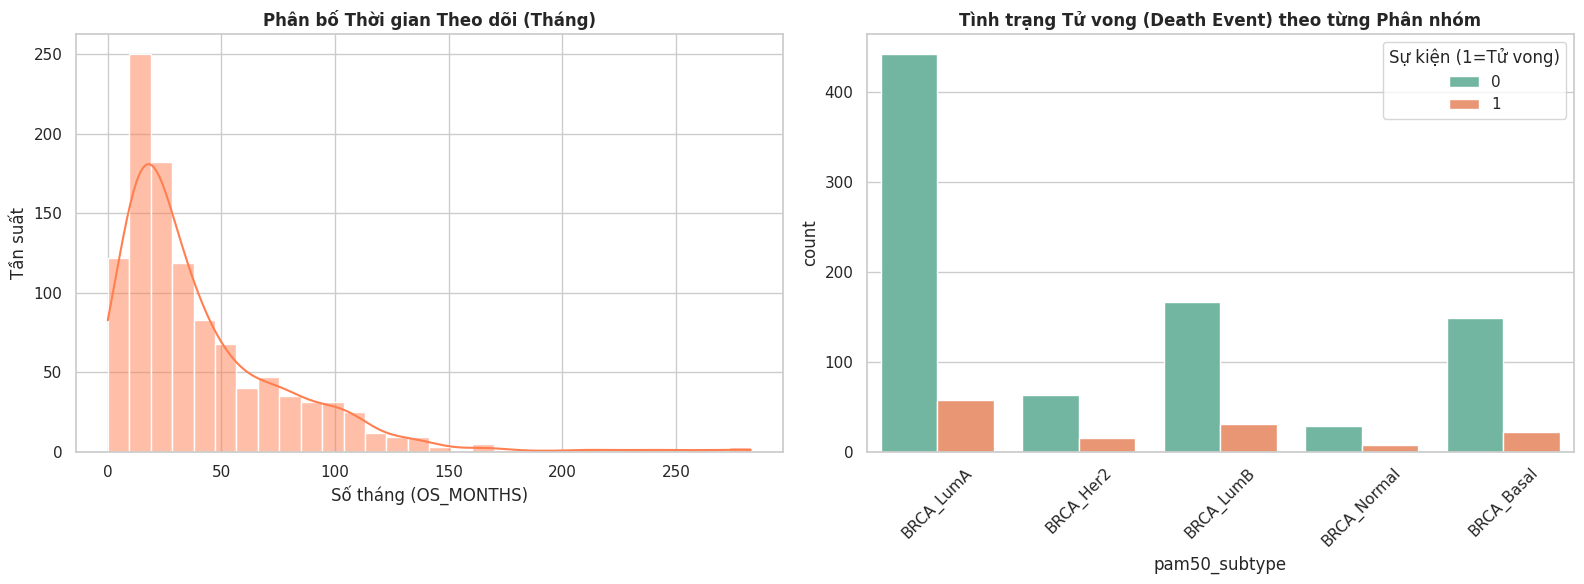

💡 KẾT LUẬN TỪ BIỂU ĐỒ:
- Phần lớn thời gian theo dõi tập trung ở mức 0 - 100 tháng.
- Một tỷ lệ lớn bệnh nhân vẫn đang sống (Censored data - Nhãn 0). Mô hình LSTM dự báo rủi ro sinh tồn cần phải xử lý được hiện tượng Censoring này.


In [4]:
if not df.empty and 'OS_MONTHS' in df.columns and 'OS_STATUS' in df.columns:
    # Tiền xử lý OS_STATUS: Chuyển '0:LIVING' thành 0, '1:DECEASED' thành 1
    df['Death_Event'] = df['OS_STATUS'].apply(lambda x: 1 if '1' in str(x) else 0)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Phân bố thời gian sinh tồn
    sns.histplot(df['OS_MONTHS'].dropna(), bins=30, kde=True, ax=ax1, color="coral")
    ax1.set_title("Phân bố Thời gian Theo dõi (Tháng)", fontweight='bold')
    ax1.set_xlabel("Số tháng (OS_MONTHS)")
    ax1.set_ylabel("Tần suất")
    
    # So sánh tình trạng sinh tồn theo Phân nhóm
    if 'pam50_subtype' in df.columns:
        sns.countplot(data=df, x='pam50_subtype', hue='Death_Event', ax=ax2, palette="Set2")
        ax2.set_title("Tình trạng Tử vong (Death Event) theo từng Phân nhóm", fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
        ax2.legend(title='Sự kiện (1=Tử vong)', loc='upper right')
        
    plt.tight_layout()
    plt.show()
    
    print("💡 KẾT LUẬN TỪ BIỂU ĐỒ:")
    print("- Phần lớn thời gian theo dõi tập trung ở mức 0 - 100 tháng.")
    print("- Một tỷ lệ lớn bệnh nhân vẫn đang sống (Censored data - Nhãn 0). Mô hình LSTM dự báo rủi ro sinh tồn cần phải xử lý được hiện tượng Censoring này.")

## Bước 4: Yếu tố Nhân khẩu học và Lâm sàng (Age & Stage)

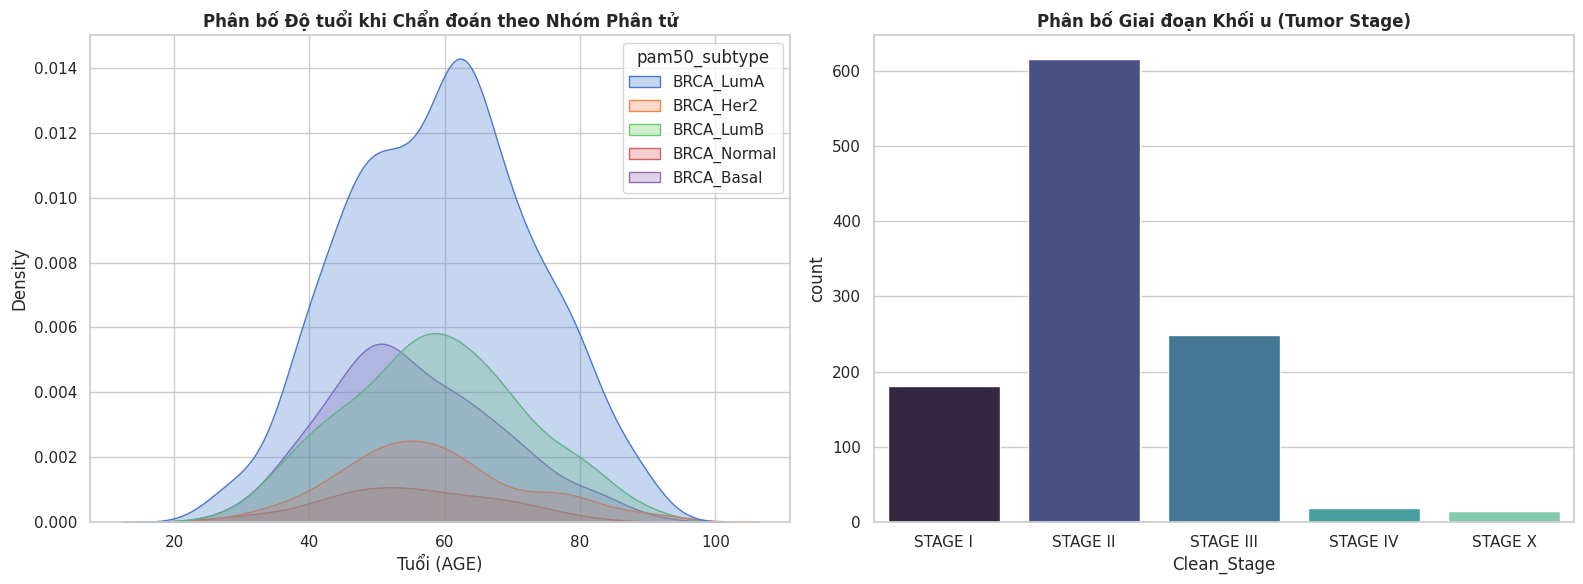

In [5]:
if not df.empty and 'AGE' in df.columns and 'AJCC_PATHOLOGIC_TUMOR_STAGE' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Phân bố độ tuổi
    sns.kdeplot(data=df, x="AGE", hue="pam50_subtype", fill=True, alpha=0.3, ax=ax1)
    ax1.set_title("Phân bố Độ tuổi khi Chẩn đoán theo Nhóm Phân tử", fontweight='bold')
    ax1.set_xlabel("Tuổi (AGE)")
    
    # Phân bố Giai đoạn Bệnh
    # Làm sạch tên giai đoạn (bỏ các chữ A, B, C nhỏ để gom nhóm chuẩn)
    df['Clean_Stage'] = df['AJCC_PATHOLOGIC_TUMOR_STAGE'].str.extract(r'(STAGE [IVX]+)')
    sns.countplot(data=df.dropna(subset=['Clean_Stage']), x='Clean_Stage', 
                  order=['STAGE I', 'STAGE II', 'STAGE III', 'STAGE IV', 'STAGE X'], ax=ax2, palette="mako")
    ax2.set_title("Phân bố Giai đoạn Khối u (Tumor Stage)", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## Bước 5: Kiểm tra Dữ liệu Ảnh (WSI Patches) & Khớp nối
Bây giờ, chúng ta sẽ kiểm tra thư mục chứa ảnh trên Kaggle. Quan trọng nhất: Liệu ID của thư mục ảnh có khớp với cột `patientId` trong file CSV không?

In [6]:
if os.path.exists(WSI_DIR) and not df.empty:
    # Lấy danh sách folder ảnh hiện có
    image_folders = [f for f in os.listdir(WSI_DIR) if os.path.isdir(os.path.join(WSI_DIR, f))]
    csv_patients = df['patientId'].dropna().astype(str).tolist()
    
    # Tìm kiếm sự trùng khớp
    matched_patients = list(set(image_folders).intersection(set(csv_patients)))
    
    print(f"📊 THỐNG KÊ KHỚP NỐI (CROSS-MATCHING):")
    print(f"- Số lượng folder bệnh nhân trong WSIs: {len(image_folders)}")
    print(f"- Số lượng bệnh nhân trong CSV: {len(csv_patients)}")
    print(f"- Số lượng bệnh nhân khớp nhau hoàn toàn: {len(matched_patients)}")
    
    if len(matched_patients) > 0:
        print("\n✅ Tuyệt vời! Hai bộ dữ liệu đã được map thành công qua PatientID. Chúng ta có thể bắt đầu ghép ảnh và nhãn.")
    else:
        print("\n⚠️ Cảnh báo: Tên folder ảnh không khớp với mã bệnh nhân trong CSV. Cần viết hàm tiền xử lý chuỗi (string manipulation) ở bước sau.")

📊 THỐNG KÊ KHỚP NỐI (CROSS-MATCHING):
- Số lượng folder bệnh nhân trong WSIs: 1021
- Số lượng bệnh nhân trong CSV: 1084
- Số lượng bệnh nhân khớp nhau hoàn toàn: 1007

✅ Tuyệt vời! Hai bộ dữ liệu đã được map thành công qua PatientID. Chúng ta có thể bắt đầu ghép ảnh và nhãn.


### Trực Quan Hóa Tế Bào Bệnh Học (WSI Patches)
Để kết thúc Notebook EDA này, chúng ta hãy in ra ngẫu nhiên một vài mảng tế bào (patches) của một vài bệnh nhân đã xác định được nhãn.

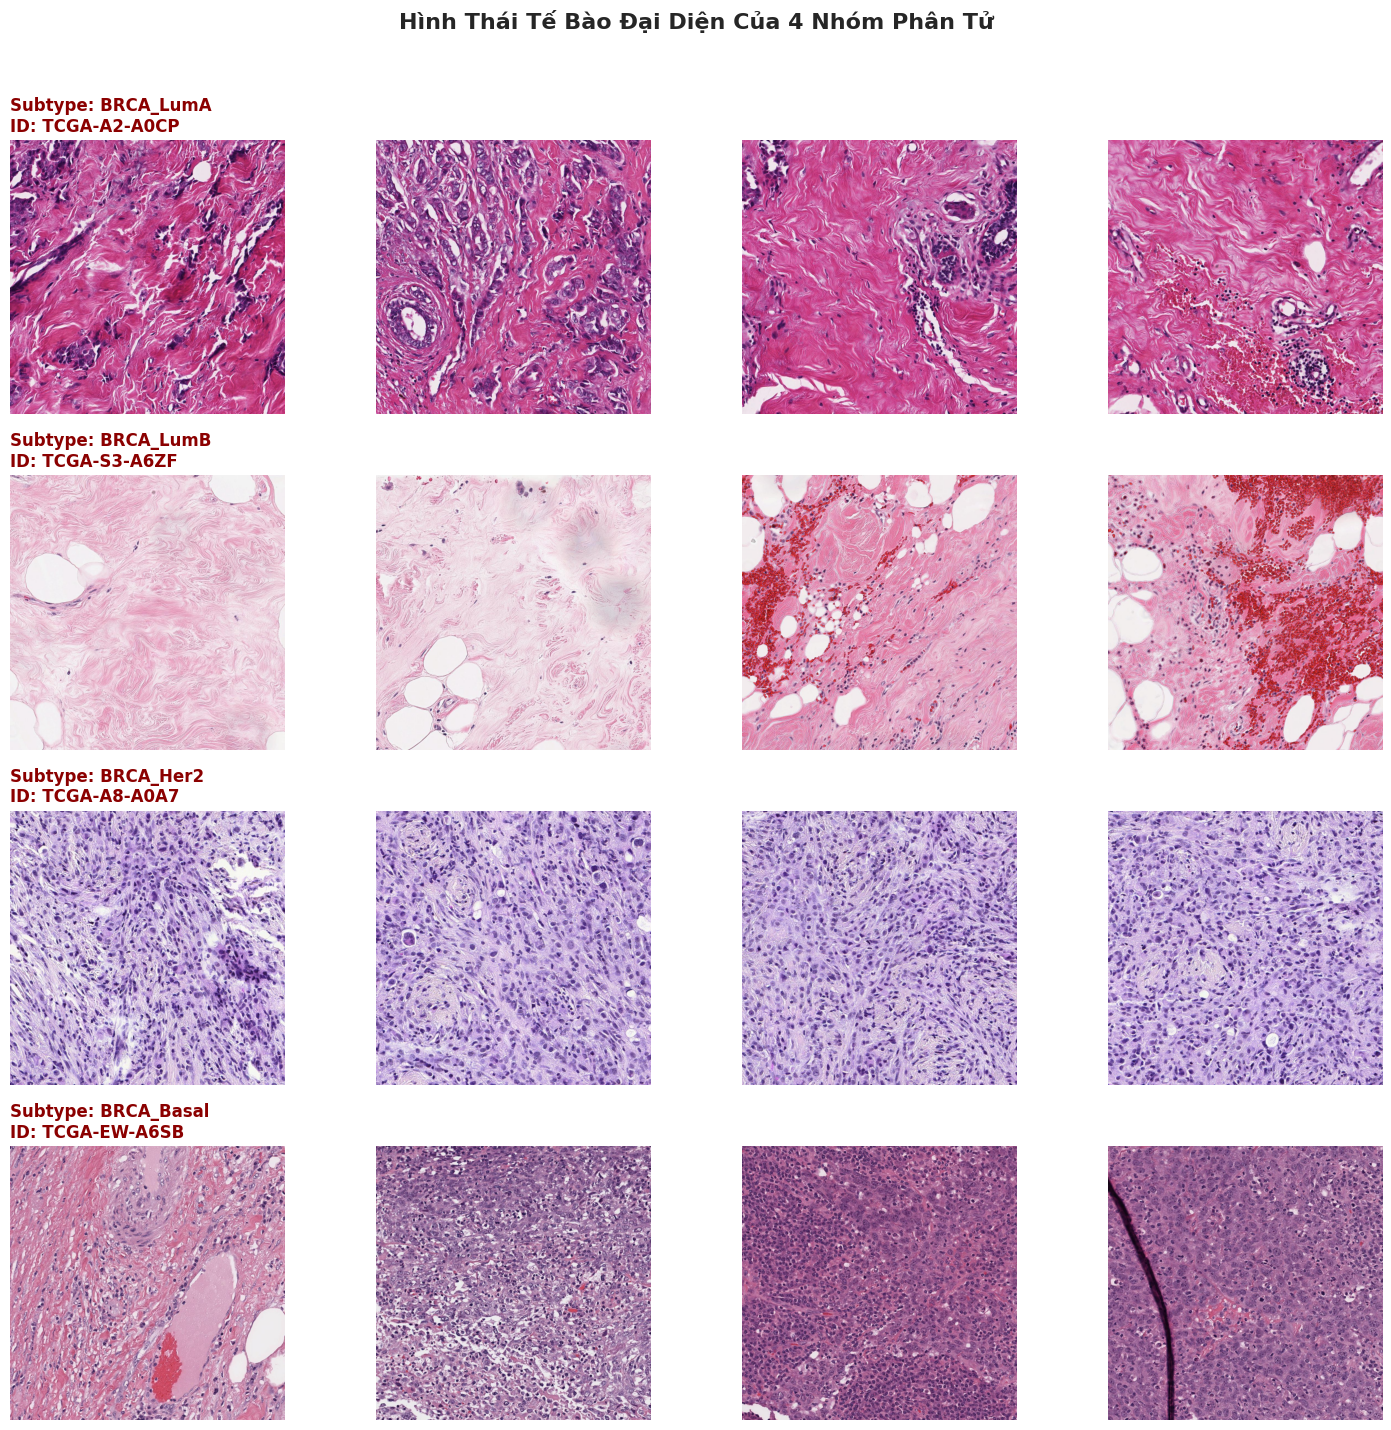

In [7]:
def show_4_subtypes_patches(wsi_dir, df, matched_list, patches_per_patient=4):
    if not matched_list or not os.path.exists(wsi_dir):
        print("Không thể trực quan hóa do chưa có ảnh hoặc chưa khớp ID.")
        return
        
    subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Her2', 'BRCA_Basal']
    selected_pids = []
    
    # Cố gắng lấy 1 bệnh nhân đại diện cho mỗi Subtype
    for st in subtypes:
        st_patients = df[(df['pam50_subtype'] == st) & (df['patientId'].isin(matched_list))]['patientId'].tolist()
        if st_patients:
            selected_pids.append((st, random.choice(st_patients)))
            
    if not selected_pids:
        print("Không tìm thấy bệnh nhân nào có nhãn phù hợp để hiển thị.")
        return
        
    fig, axes = plt.subplots(len(selected_pids), patches_per_patient, figsize=(15, 3.5 * len(selected_pids)))
    if len(selected_pids) == 1:
        axes = [axes]
        
    for i, (subtype, pid) in enumerate(selected_pids):
        p_dir = os.path.join(wsi_dir, pid)
        patches = [p for p in os.listdir(p_dir) if p.endswith('.jpg')]
        selected_patches = random.sample(patches, min(patches_per_patient, len(patches)))
        
        for j, patch_name in enumerate(selected_patches):
            img_path = os.path.join(p_dir, patch_name)
            try:
                img = Image.open(img_path)
                ax = axes[i][j] if patches_per_patient > 1 else axes[i]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_title(f"Subtype: {subtype}\nID: {pid}", fontsize=12, fontweight='bold', color='darkred', loc='left')
            except:
                pass
                
    plt.suptitle("Hình Thái Tế Bào Đại Diện Của 4 Nhóm Phân Tử", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

if 'matched_patients' in locals():
    show_4_subtypes_patches(WSI_DIR, df, matched_patients)

# Xuất bảng dữ liệu lâm sàng đã xử lý sạch ra thư mục working
if "df_clean" in locals():
    df_clean.to_csv("/kaggle/working/tcga_brca_clinical_clean.csv", index=False)
elif "df" in locals():
    df.to_csv("/kaggle/working/tcga_brca_clinical_clean.csv", index=False)
print("✓ Đã lưu bảng dữ liệu lâm sàng sạch vào /kaggle/working/tcga_brca_clinical_clean.csv")

### 🔬 Lý Thuyết Hình Thái Học (Morphology) Của 4 Nhóm Phân Tử

Để hiểu cách mô hình AI học, chúng ta cần đóng vai trò là một bác sĩ giải phẫu bệnh thực thụ. 4 nhóm phân tử này không chỉ khác biệt ở cấp độ gen (DNA/RNA) mà còn bộc lộ những khác biệt vi thể trên ảnh WSI:

| Phân nhóm | Mức độ ác tính (Grade) | Đặc điểm Hình thái tế bào (Morphological Features) | AI (ResNet + TransMIL) sẽ học như thế nào? |
|---|---|---|---|
| **Luminal A (LumA)** | Thấp (Low-grade) | Tế bào phân hóa tốt, khá giống mô tuyến vú bình thường. Hình thái nhân nhỏ, đều đặn, tỷ lệ phân bào (mitosis) cực kỳ thấp. Mô đệm (stroma) có thể phản ứng sợi hóa nhẹ. | Khá dễ nhận biết. AI sẽ tìm kiếm các vùng mô có cấu trúc ống tuyến (tubules) còn giữ được hình dạng, mật độ tế bào không quá dày đặc, và hạt nhân đồng đều. |
| **Luminal B (LumB)** | Trung bình - Cao | Tế bào phân hóa kém hơn LumA. Nhân tế bào to hơn, mất cân xứng (pleomorphism) rõ rệt. **Đặc điểm nhận diện chính:** Tỷ lệ phân bào cao (nhiều tế bào đang nhân đôi). | AI sẽ tập trung vào sự đa hình của nhân tế bào và mật độ tế bào dày đặc hơn. Khó khăn: Dễ nhầm lẫn với HER2 nếu khối u có cấu trúc tương tự. |
| **HER2-enriched** | Cao (High-grade) | Tế bào rất to, nhân thô và lớn (high nuclear pleomorphism). Có nhiều vùng hoại tử (necrosis) ở trung tâm. Tỷ lệ phân bào rất cao. | Khó khăn lớn cho AI: Hình thái của nhóm này dao động rất mạnh, thường chồng chéo với LumB. AI sẽ tìm kiếm các mảng tế bào to, viền tế bào không rõ ràng và vùng mô hoại tử, nhưng cần Weighted Loss để ép mạng chú ý kỹ hơn. |
| **Basal-like** | Rất Cao (Highest-grade) | Cấu trúc khối u dày đặc (solid sheets), không còn hình dáng ống tuyến. **Đặc trưng nhận diện:** Bờ khối u thường là "bờ đẩy" (pushing border) rất rõ nét, xung quanh có rất nhiều tế bào lympho xâm nhập (Lymphocytic infiltration). | Dễ nhận biết nhất trong các nhóm ác tính cao. Chú ý của AI (Attention) thường sẽ tập trung mạnh vào các dải tế bào lympho vây quanh khối u và cấu trúc mảng đặc (solid pattern) của tế bào ung thư. |

**💡 Kết luận:** Việc kết hợp **ResNet50** (Giỏi nhận diện các texture nhỏ như hạt nhân, viền tế bào) và **TransMIL** (Giỏi nhìn tổng quan cấu trúc không gian như sự phân bố của lympho và mô đệm) là sự kết hợp hoàn hảo để giải mã các đặc điểm hình thái học phức tạp này.

---
### 🏆 TỔNG KẾT NOTEBOOK 1:
1. Chúng ta đã làm chủ được file CSV `tcga_brca_master_matched_cohort.csv`.
2. Xác định được 2 cột nhãn cực kỳ quan trọng:
   - `pam50_subtype` (Cho bài toán Classification)
   - `OS_STATUS` & `OS_MONTHS` (Cho bài toán Survival).
3. Chứng minh được sự mất cân bằng lớp ở các phân nhóm phân tử.
4. Xác nhận sự liên kết thành công giữa **Bệnh án Lâm sàng** và **Ảnh Mô bệnh học** thông qua mã `patientId`.

**👉 Bước tiếp theo (Notebook 2):** Sử dụng mạng CNN (ResNet50) để biến hàng nghìn tấm ảnh `.jpg` của mỗi bệnh nhân thành một ma trận vector toán học đặc trưng (Feature Tensors) nhằm chuẩn bị đưa vào mạng Transformer!